In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
from scipy import stats
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib_venn import venn2
import scanpy as sc
import scrublet as scr
import scanpy.external as sce

In [2]:
sc.settings.verbosity = 3
sc.set_figure_params(dpi=100, dpi_save=150, facecolor="white")

In [3]:
adata_SALL2KO = sc.read_10x_mtx("filtered_feature_bc_matrix",
                               var_names = "gene_symbols",
                               make_unique = True,
                               cache = True)

... reading from cache file cache\filtered_feature_bc_matrix-matrix.h5ad


In [4]:
adata_SALL2KO.obs

""
AAACAGCCAACCCTAA-1
AAACAGCCAATCCTGA-1
AAACAGCCACAAGCCT-1
AAACAGCCAGGCTTGT-1
AAACAGCCATTGCAGC-1
...
TTTGTTGGTGGTTCTT-1
TTTGTTGGTTACCTGT-1
TTTGTTGGTTAGTTGG-1
TTTGTTGGTTGCCTCA-1


In [5]:
adata_SALL2KO.var

,gene_ids,feature_types
MIR1302-2HG,ENSG00000243485,Gene Expression
FAM138A,ENSG00000237613,Gene Expression
OR4F5,ENSG00000186092,Gene Expression
AL627309.1,ENSG00000238009,Gene Expression
AL627309.3,ENSG00000239945,Gene Expression
...,...,...
AC141272.1,ENSG00000277836,Gene Expression
AC023491.2,ENSG00000278633,Gene Expression
AC007325.1,ENSG00000276017,Gene Expression
AC007325.4,ENSG00000278817,Gene Expression


In [6]:
adata_SALL2KO.X.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [7]:
adata_SALL2KO_GOI = adata_SALL2KO[:,adata_SALL2KO.var.index == "SOX2"]
print(adata_SALL2KO_GOI.X.toarray())
print(adata_SALL2KO_GOI.X.toarray().mean())
print(adata_SALL2KO_GOI.X.toarray().max())

[[1.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [1.]]
1.179375
23.0


In [8]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata_SALL2KO.var["mt"] = adata_SALL2KO.var_names.str.startswith("MT-")
# ribosomal genes
adata_SALL2KO.var["ribo"] = adata_SALL2KO.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata_SALL2KO.var["hb"] = adata_SALL2KO.var_names.str.contains("^HB[^(P)]")

In [9]:
sc.pp.calculate_qc_metrics(
    adata_SALL2KO, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

C:\Users\huangq\Anaconda3\envs\Python_Scanpy_v5\lib\site-packages\anndata\_core\anndata.py:1228: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed in a future version. Reordering categories will always return a new Categorical object.
  c.reorder_categories(natsorted(c.categories), inplace=True)
... storing 'feature_types' as categorical
C:\Users\huangq\Anaconda3\envs\Python_Scanpy_v5\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


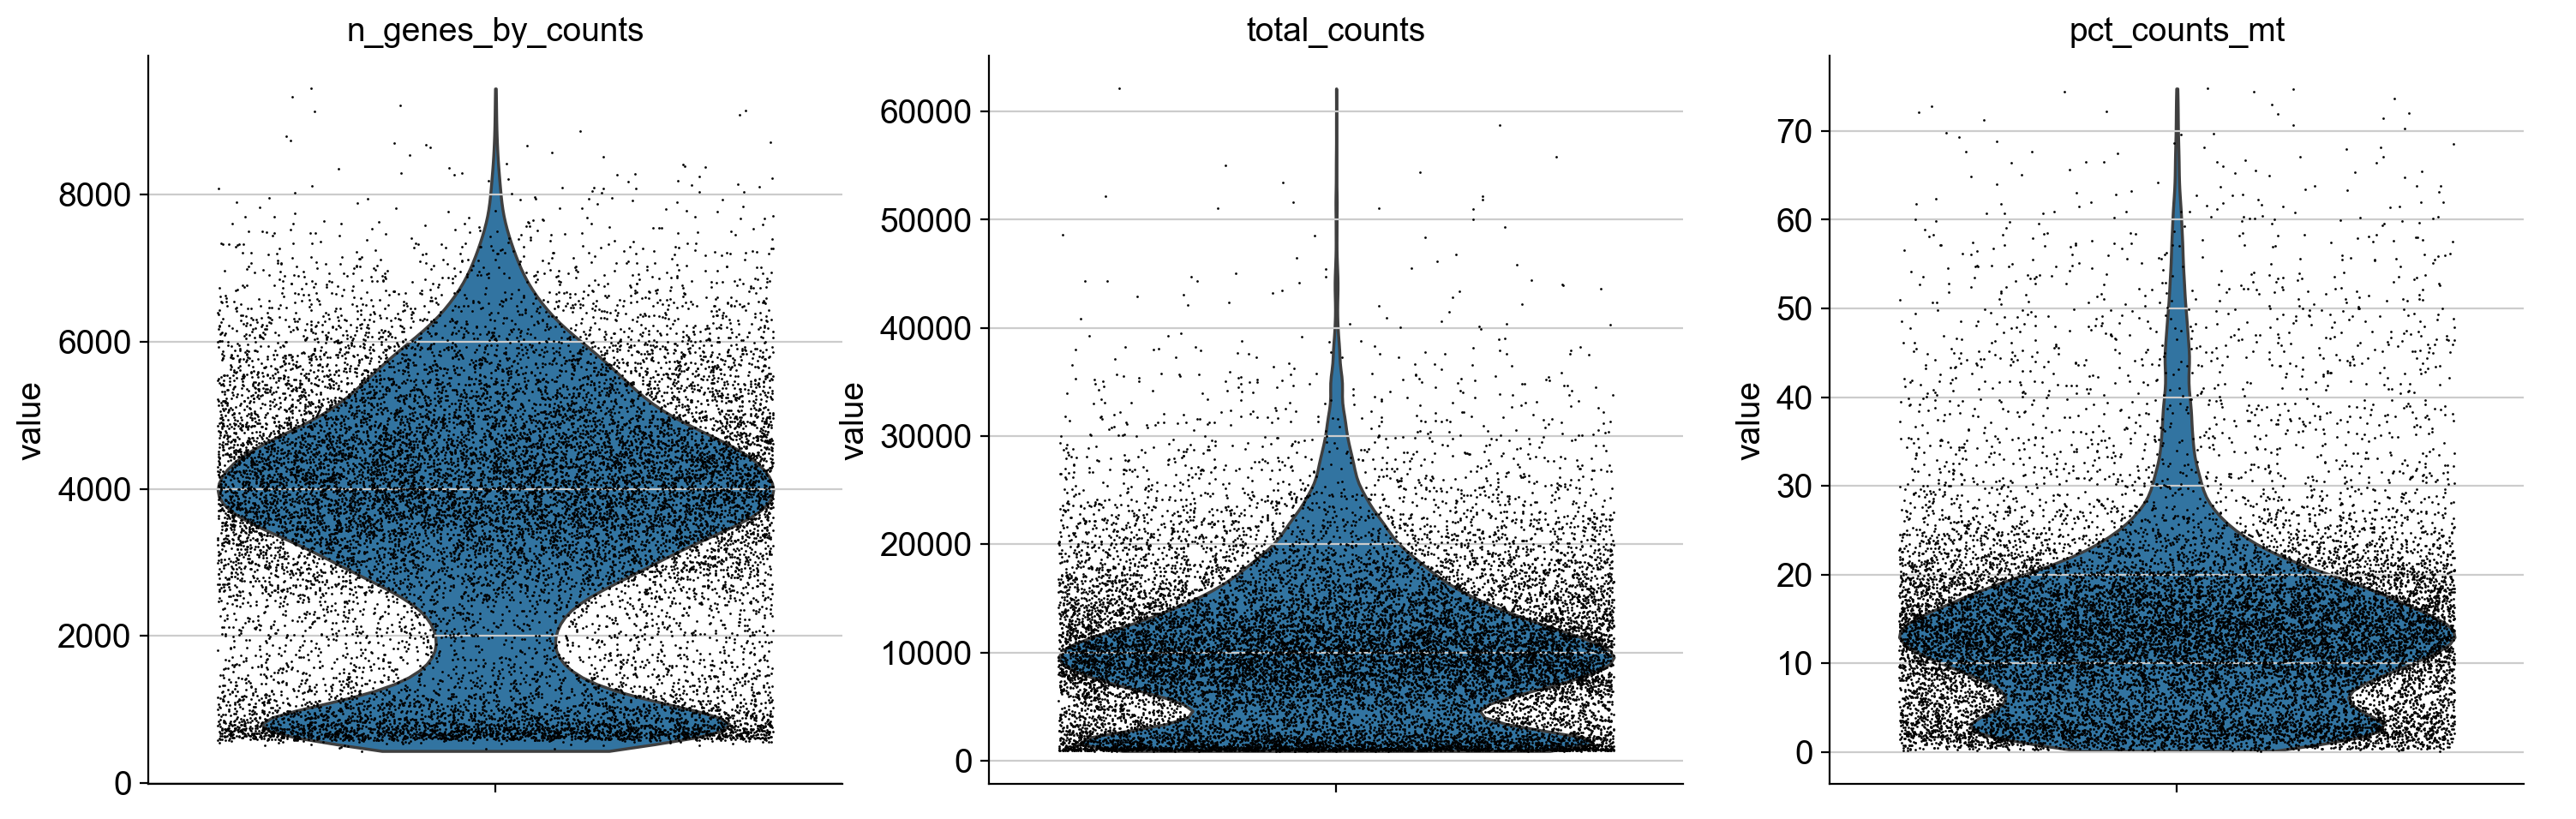

In [10]:
sc.pl.violin(
    adata_SALL2KO,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

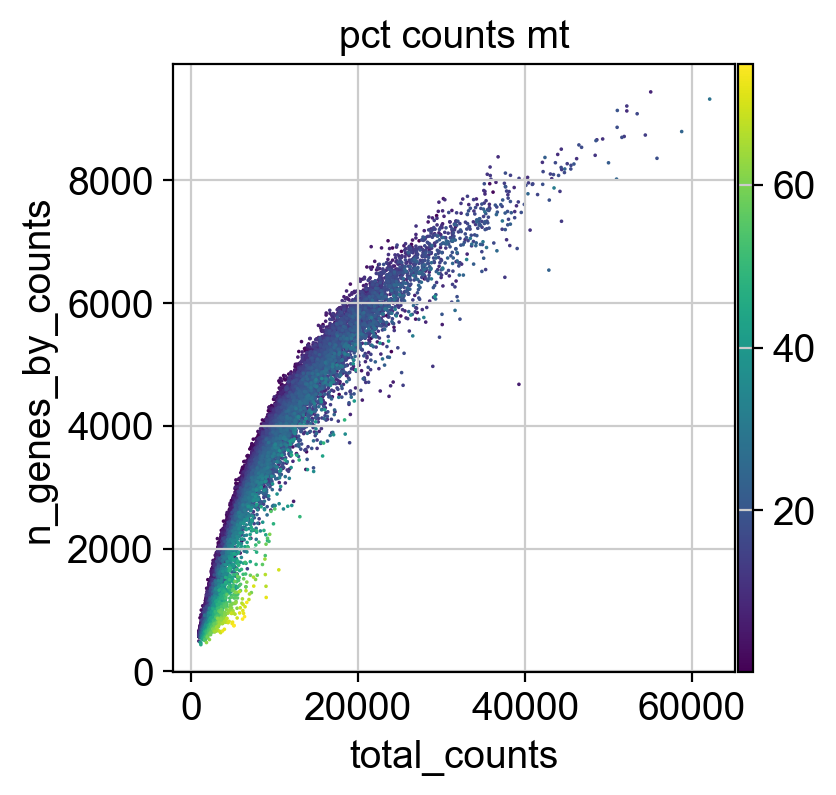

In [11]:
sc.pl.scatter(adata_SALL2KO, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [12]:
sc.pp.filter_cells(adata_SALL2KO, min_genes=100)
sc.pp.filter_genes(adata_SALL2KO, min_cells=3)

filtered out 6768 genes that are detected in less than 3 cells


In [13]:
adata_SALL2KO.write('B10_SALL2KO_savepoint1.h5ad')

In [15]:
sce.pp.scrublet(adata_SALL2KO)

Running Scrublet
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


C:\Users\huangq\Anaconda3\envs\Python_Scanpy_v5\lib\site-packages\scanpy\preprocessing\_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
Automatically set threshold at doublet score = 0.54
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%
    Scrublet finished (0:01:51)


In [19]:
sum(adata_SALL2KO.obs['predicted_doublet'] == True)

0

In [21]:
# Saving count data
adata_SALL2KO.layers["counts"] = adata_SALL2KO.X.copy()

In [22]:
# Normalizing to median total counts
sc.pp.normalize_total(adata_SALL2KO)
# Logarithmize the data
sc.pp.log1p(adata_SALL2KO)

normalizing counts per cell
    finished (0:00:00)


In [23]:
sc.pp.highly_variable_genes(adata_SALL2KO, n_top_genes=2000)

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


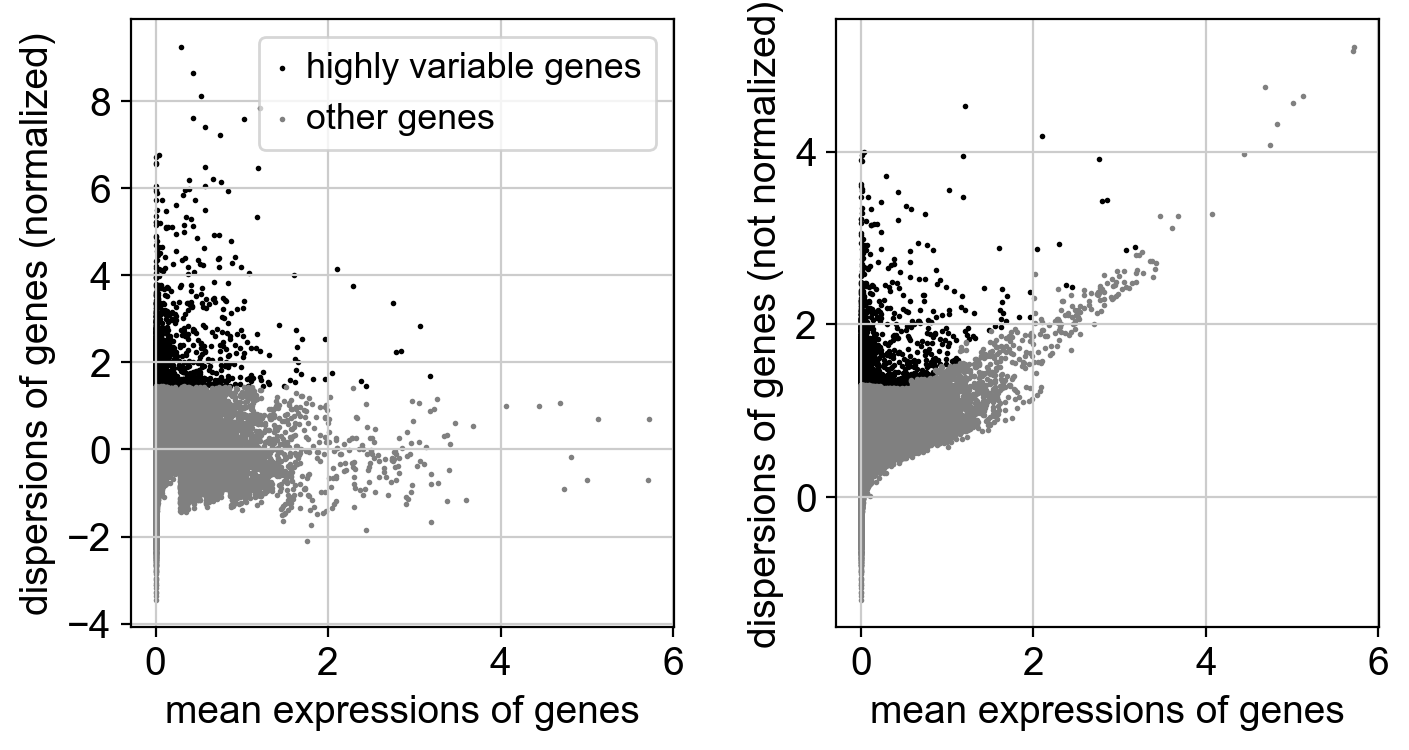

In [24]:
sc.pl.highly_variable_genes(adata_SALL2KO)

In [25]:
sc.tl.pca(adata_SALL2KO)

computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:01)


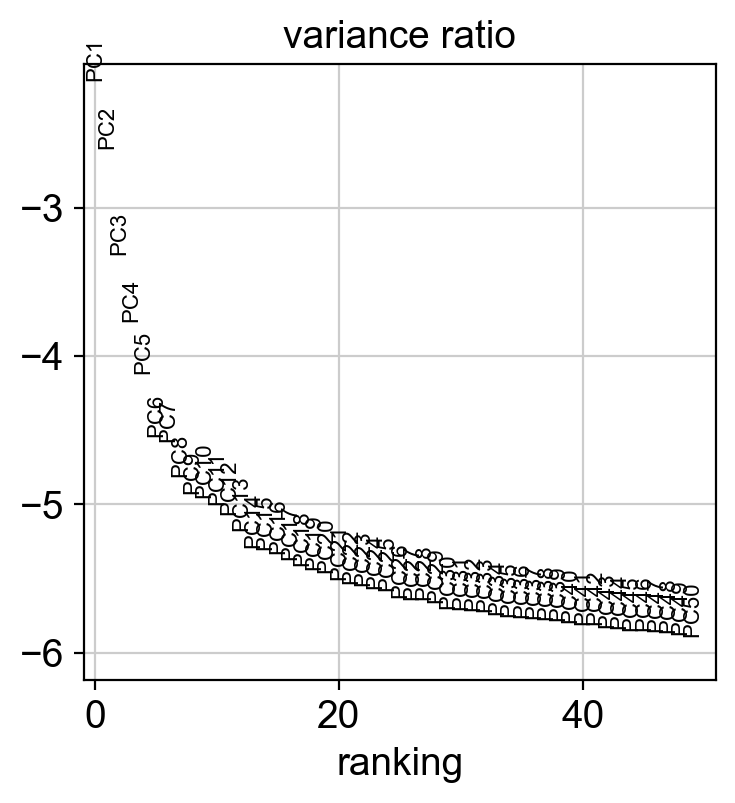

In [26]:
sc.pl.pca_variance_ratio(adata_SALL2KO, n_pcs=50, log=True)

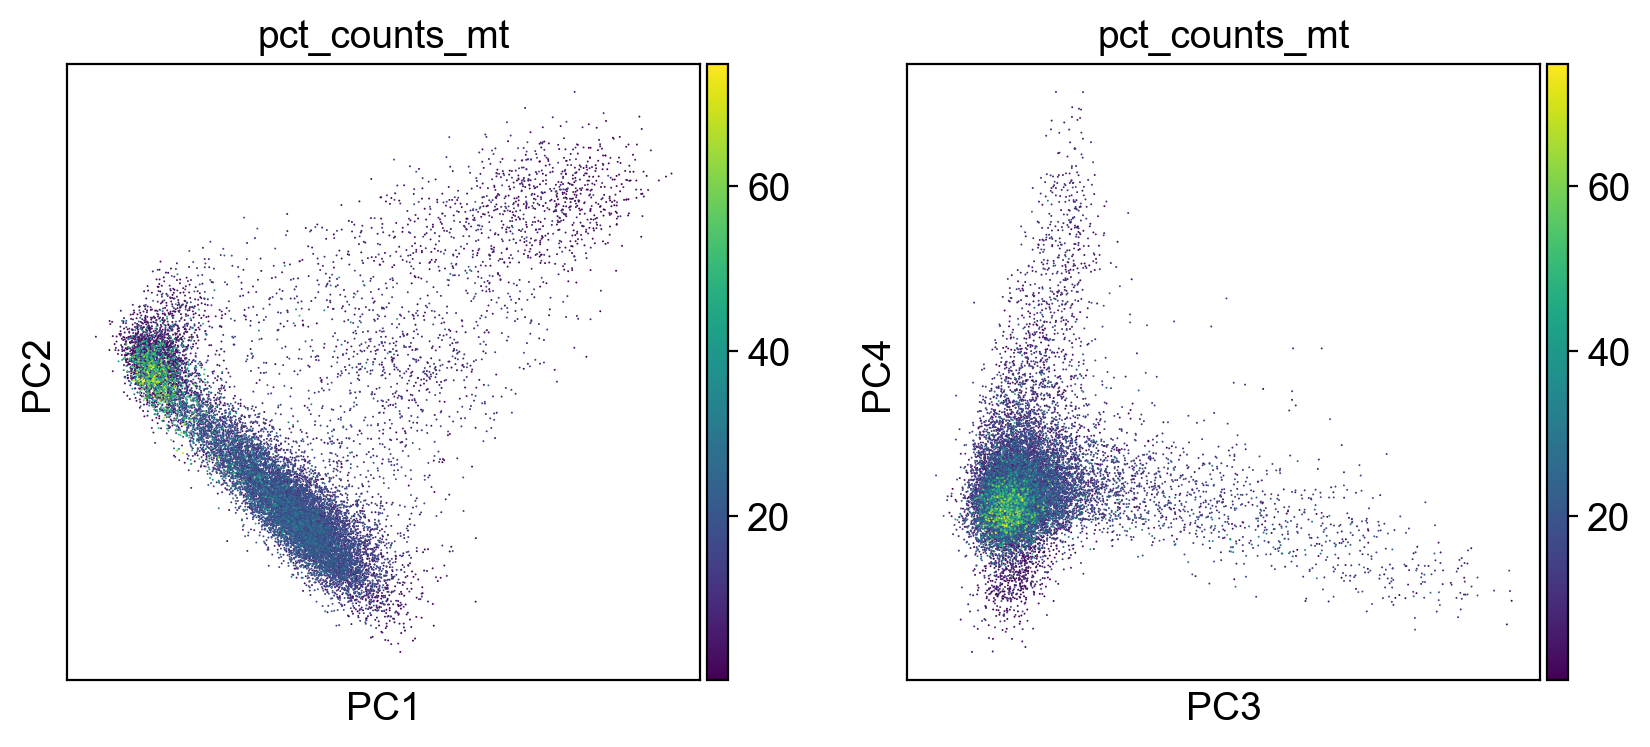

In [30]:
sc.pl.pca(
    adata_SALL2KO,
    color=["pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3)],
    ncols=2,
    size=2,
)

In [31]:
sc.pp.neighbors(adata_SALL2KO)
sc.tl.umap(adata_SALL2KO)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:18)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:15)


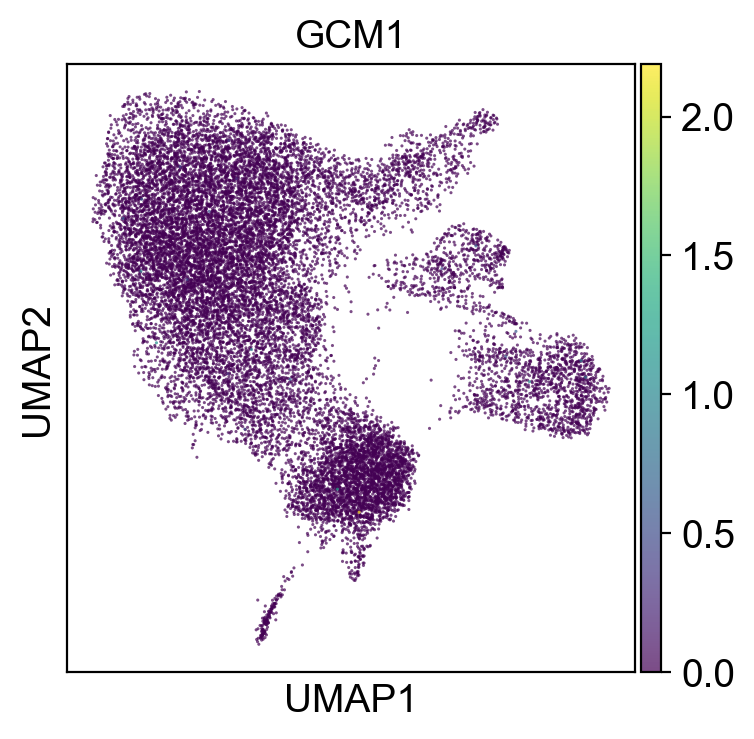

In [43]:
sc.pl.umap(
    adata_SALL2KO,
    color="GCM1",
    # Setting a smaller point size to get prevent overlap
    size=5,
    alpha = 0.7,
)

In [ ]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)